# Polynomial-ratio computation of scalar IV CUE

## Objective, numerical convergence and estimation error

An executed Trex implementation experiment based on **Moreira, Newey and Sharifvaghefi (2026), [Continuously Updating GMM in Linear IV Models: A Polynomial Approach](https://arxiv.org/abs/2609.36445v1)**.

The paper converts global scalar CUE minimization into polynomial-root enumeration plus an explicit comparison with infinity. This notebook compares that recipe with **Trex-style SciPy BFGS with central finite differences**, an **analytic-gradient BFGS control**, and **full-sample PyTorch Adam** at its default learning rate 0.001 and an explicitly specified 0.05. Adam is the first-order optimizer family used elsewhere in Trex; existing GEL does not expose an Adam CUE backend, so the benchmark supplies the same differentiable scalar criterion directly.

**Scope:** one endogenous regressor, fixed positive-definite joint covariance, CPU/float64. This is a numerical prototype, not a certified algebraic global solver. Existing GMM/GEL defaults are unchanged. The original paper's multi-endogenous-regressor elimination, singular-covariance extension, CLR inference and 10,000-replication experiments are not reproduced here.

**Saved run:** 700 independent datasets (100 per design), 9,100 optimizer/start results. The polynomial routine returned 696 validated solutions and rejected four ten-instrument cases. Every accepted solution agreed with an independent angular-grid/refinement reference to within $5.1\times10^{-12}$ in objective value. A lower CUE objective does **not** imply smaller estimation error in every finite sample.

### Source and reproducibility

The pinned arXiv TeX source was downloaded and read. Its version, checksum and contents are in [`source/manifest.json`](../benchmarks/cue_polynomial/source/manifest.json); [`source/fetch.py`](../benchmarks/cue_polynomial/source/fetch.py) re-downloads it into ignored local storage. The archive does **not** contain the online supplement or authors' MATLAB code. Chebyshev interpolation, reciprocal charts and validation thresholds below are our implementation choices, not an asserted replication of missing author code.

Reproduce the simulation from the repository root with `python -m benchmarks.cue_polynomial.experiment --replications 100`. Re-execute this notebook with a kernel using the same environment; executed outputs are retained for GitHub review. No external datasets, APIs or GPUs are required.

In [1]:
from pathlib import Path
import sys, json, gzip, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "trex/gmm/cue.py").exists())
sys.path.insert(0, str(ROOT))
from trex.gmm import ScalarIVCUE, GELEstimator, rho_cue
from benchmarks.cue_polynomial.experiment import generate, bfgs, adam_batch, run, _json_safe

torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 12)
RECOMPUTE = False  # Set True to rerun the full paired Monte Carlo, not only the figures.
if RECOMPUTE:
    saved = _json_safe(run(replications=100))
else:
    with gzip.open(ROOT / "benchmarks/cue_polynomial/results.json.gz", "rt") as f:
        saved = json.load(f)
print("Saved simulation environment:")
display(pd.Series(saved["environment"]).to_frame("value"))
print(f"{len(saved['problems'])} datasets; {len(saved['rows'])} optimizer/start results; "
      f"{saved['elapsed_seconds']:.1f} seconds for the Monte Carlo runner (including batched Adam).")

Saved simulation environment:


,value
python,3.12.11
numpy,2.4.2
scipy,1.17.0
torch,2.9.1
platform,macOS-26.6.2-arm64-arm-64bit
processor,arm64
torch_threads,1
dtype,float64
device,cpu


700 datasets; 9100 optimizer/start results; 18.3 seconds for the Monte Carlo runner (including batched Adam).


## 1. The criterion and the polynomial recipe

Let $a=Z'y/\sqrt n$, $b=Z'x/\sqrt n$, and let $\widehat\Sigma$ be a **fixed** joint covariance of the reduced-form moment vector in block order $(y,x)$. Then

$$g(\beta)=a-\beta b,\qquad
\Omega(\beta)=S_{11}-\beta(S_{12}+S_{21})+\beta^2 S_{22},\qquad
Q_n(\beta)=g(\beta)'\Omega(\beta)^{-1}g(\beta).$$

Although $\widehat\Sigma$ is fixed, $\Omega(\beta)$ and its inverse vary with every candidate $\beta$: this is continuously updated weighting. It is not Trex's two-step GMM, which holds its second-step weight fixed.

The adjugate identity gives

$$p(\beta)=g(\beta)'\operatorname{adj}\{\Omega(\beta)\}g(\beta),\quad
q(\beta)=\det\Omega(\beta),\quad Q_n=p/q.$$

For $k$ instruments, $\deg p\leq2k$, $\deg q=2k$. Since $q>0$, all finite stationary points solve

$$h(\beta)=p'(\beta)q(\beta)-p(\beta)q'(\beta)=0,\qquad \deg h\leq4k-2.$$

Compare the original matrix objective at **every real root**, including maxima, and at

$$Q_n(\pm\infty)=b'S_{22}^{-1}b.$$

If $h\equiv0$, every parameter has the same objective. With $k=1$, the finite solution is the usual IV ratio $a/b$ when $b\ne0$; the implementation uses that closed form.

### Finite-precision implementation

1. Center/scale the parameter using covariance blocks and apply an invertible instrument transformation.
2. Cover the entire real line with $|t|\leq1$ and its reciprocal chart $|1/t|\leq1$, where $t=(\beta-c)/s$. These are coordinate charts, **not parameter search bounds**.
3. Recover degree-$2k$ numerator and denominator coefficients from $2k+1$ Chebyshev nodes, using determinant evaluations and matrix solves rather than symbolic inversion.
4. Solve the Chebyshev companion eigenproblems for $p'q-pq'$, retain real roots in each chart, polish/check using analytic derivatives of the matrix criterion, and compare candidate values with infinity.
5. Validate the recovered ratio at independent interpolation probes. Reject failed interpolation/root checks; never silently add a ridge or substitute a local optimizer.

The prototype is limited to $k\leq12$. Float64 companion roots and pointwise checks do not certify completeness; `certified=False` is intentional. Multiple or nearly real roots and ill-conditioned covariance matrices remain numerical concerns.

### Two weighting definitions, explicitly separated

The primary panel constructs HC0 $\widehat\Sigma$ from $Z_i\widehat V_i$, where $\widehat V=(I-P_Z)(y,x)$ contains reduced-form OLS residuals after demeaning. This follows the paper's fixed joint-covariance setup.

The separate **raw** panel constructs it from $Z_i(y_i,x_i)$ itself. Then $\Omega(\beta)=n^{-1}\sum_i Z_iZ_i'(y_i-\beta x_i)^2$, exactly the uncentered structural-moment weighting behind existing `GELEstimator(rho=rho_cue)`. Its profiled objective is $Q_n/(2n)$. These two finite-sample criteria are not conflated. All optimizers within a panel receive the identical criterion.

In [2]:
z, y, x, tsls = generate(seed=930321, k=4, concentration=16)
problem = ScalarIVCUE.from_data(z, y, x, demean=False)
solution = problem.minimize_polynomial()
display(pd.Series({"2SLS": tsls, "polynomial CUE": solution.beta,
                   "Q minimum candidate": solution.fun,
                   "Q at infinity": problem.value(np.inf),
                   "finite coefficient": not solution.at_infinity,
                   "numerically constant": solution.constant,
                   "certified": solution.certified}).to_frame("value"))
display(pd.DataFrame(solution.diagnostics["charts"]))

,value
2SLS,5.436356
polynomial CUE,5.254948
Q minimum candidate,2.694648
Q at infinity,22.858153
finite coefficient,True
numerically constant,False
certified,False


,reciprocal,degree,ratio_error,denominator_error,max_stationarity_residual
0,False,14,1.472224e-14,1.065814e-14,2.372408e-12
1,True,14,8.775999e-16,1.998401e-15,0.000000e+00


## 2. Paired simulation design

We use the paper's Section 5.1 design:

$$x_i=\sqrt{\mu^2/n}\,z_i+v_i,\quad y_i=5x_i+u_i,$$
$$u_i=0.6v_i+0.8\{\sqrt{1/2}\,z_ie_{1i}+\sqrt{1/2}\,e_{2i}\},$$

where $z,v,e_1,e_2$ are independent standard normals. Each dataset has $n=800$. Instruments are $z$ for $k=1$; $(z,z^2,z^3,z^4)$ for $k=4$; and those powers plus six independent Bernoulli-$1/2$ interactions with $z$ for $k=10$. Outcome, endogenous regressor and all instruments are demeaned. The primary configurations are $(k,\mu^2)=(1,1),(4,1),(4,4),(4,16),(10,4),(10,64)$. The last is an additional stronger-identification diagnostic, not a reported paper configuration. A raw-weighting $(4,4)$ panel is separate.

Each of 100 datasets per configuration is reused across all methods and three starts: **2SLS**, **zero**, and **truth=5 (infeasible diagnostic)**. No starting value is needed by the polynomial method. Raw and reduced-form panels have their own seeds; do not interpret differences between their Monte Carlo summaries as paired weighting comparisons.

- BFGS minimizes $Q_n/n$, with `tol=1e-9`, `maxiter=2000`. The Trex-style baseline uses the same central finite-difference helper as `GMMEstimatorScipy`; the analytic-gradient control removes derivative-approximation error.
- Adam minimizes exactly the same $Q_n/n$, with PyTorch defaults except the stated learning rate, maximum **3,000 updates**, and a stopping rule $|\partial(Q_n/n)/\partial\beta|\leq10^{-9}$. Both learning rates were specified before the full simulation. No validation-set tuning is claimed.
- Adam's independent fits are batched for Monte Carlo throughput, with a **sum**, not mean, across fit objectives. Each fit has its own moments and optimizer state; completed fits freeze. There is no minibatching over observations. Amortized batch timings are not presented as serial latency.
- An independent 2,049-point **angular** grid on the compactified line, followed by bounded refinement of each detected local minimum, checks the polynomial result. This reference is numerical, not an exact certificate.

A recovered objective means $Q_{\rm returned}-Q_{\rm reference}\leq10^{-6}(1+|Q_{\rm reference}|)$. Optimizer `success` means only that its local stopping rule passed. Estimation error is separately $\widehat\beta-5$. Unconverged returned iterates remain in error summaries; missing or infinite estimates are counted explicitly rather than treated as zero.

In [3]:
keys = ["weighting", "k", "concentration", "replication"]
df = pd.DataFrame(saved["rows"])
ref = pd.DataFrame([{**{k:p[k] for k in keys}, "reference_Q":p["grid_reference"],
                     "reference_beta":p["grid_beta"], "poly_rejected":"error" in p}
                    for p in saved["problems"]])
df = df.merge(ref, on=keys, validate="many_to_one")
df["objective_gap"] = df.objective-df.reference_Q
df["recovered"] = df.objective_gap.le(1e-6*(1+df.reference_Q.abs())) & df.objective.notna()
df["error"] = df.beta-5

def summarize(group):
    finite = group[np.isfinite(group.beta)]
    err = finite.error.to_numpy()
    return pd.Series({"N":len(group), "finite_N":len(finite),
                      "optimizer_success_%":100*group.success.mean(),
                      "objective_recovered_%":100*group.recovered.mean(),
                      "median_bias":np.median(err), "median_abs_error":np.median(abs(err)),
                      "RMSE":np.sqrt(np.mean(err**2)),
                      "90%_range":np.quantile(err,.95)-np.quantile(err,.05)})
primary = df[df.weighting.eq("reduced_form")]
from_2sls = primary[primary.start.eq("2SLS") | primary.method.eq("Polynomial")]
summary = from_2sls.groupby(["k","concentration","method"]).apply(summarize, include_groups=False)
display(summary.round(3))
print("All non-polynomial methods in this table start at 2SLS. Failed polynomial returns reduce finite_N, not N.")

N  finite_N  optimizer_success_%  \
k  concentration method                                                
1  1             Adam lr=0.001  100.0     100.0                100.0   
                 Adam lr=0.05   100.0     100.0                100.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0     100.0                100.0   
4  1             Adam lr=0.001  100.0     100.0                 51.0   
                 Adam lr=0.05   100.0     100.0                 89.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0     100.0                100.0   
   4             Adam lr=0.001  100.0     100.0                 62.0   
                 Adam lr=0.05   100.0     100.0                 88.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0     100.0                100.0   
   16            Adam lr=0.001  100.0     100.0                 86.0   
                 Adam lr=0.05   100.0     100.0                 98.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0     100.0                100.0   
10 4             Adam lr=0.001  100.0     100.0                 59.0   
                 Adam lr=0.05   100.0     100.0                 94.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0      99.0                 99.0   
   64            Adam lr=0.001  100.0     100.0                 96.0   
                 Adam lr=0.05   100.0     100.0                100.0   
                 BFGS Trex FD   100.0     100.0                100.0   
                 BFGS analytic  100.0     100.0                100.0   
                 Polynomial     100.0      97.0                 97.0   

                                objective_recovered_%  median_bias  \
k  concentration method                                              
1  1             Adam lr=0.001                  100.0        0.215   
                 Adam lr=0.05                   100.0        0.215   
                 BFGS Trex FD                   100.0        0.215   
                 BFGS analytic                  100.0        0.215   
                 Polynomial                     100.0        0.215   
4  1             Adam lr=0.001                   59.0        0.408   
                 Adam lr=0.05                    84.0        0.408   
                 BFGS Trex FD                    88.0        0.408   
                 BFGS analytic                   88.0        0.408   
                 Polynomial                     100.0        0.502   
   4             Adam lr=0.001                   64.0        0.149   
                 Adam lr=0.05                    87.0        0.149   
                 BFGS Trex FD                    94.0        0.149   
                 BFGS analytic                   94.0        0.149   
                 Polynomial                     100.0        0.142   
   16            Adam lr=0.001                   89.0       -0.009   
                 Adam lr=0.05                    98.0       -0.009   
                 BFGS Trex FD                    99.0       -0.009   
                 BFGS analytic                   99.0       -0.009   
                 Polynomial                     100.0       -0.027   
10 4             Adam lr=0.001                   57.0        0.282   
                 Adam lr=0.05                    86.0        0.282   
                 BFGS Trex FD                    90

All non-polynomial methods in this table start at 2SLS. Failed polynomial returns reduce finite_N, not N.


In [4]:
starts = primary[~primary.method.eq("Polynomial")].groupby(["method","start"]).apply(summarize, include_groups=False)
display(starts[["N","optimizer_success_%","objective_recovered_%","median_abs_error","RMSE"]].round(3))
print("Polynomial interpolation/derivative-check rejections:")
failed = pd.DataFrame([{k:p[k] for k in ["weighting","k","concentration","seed","error"]}
                       for p in saved["problems"] if "error" in p])
display(failed)
gaps = [abs(p["polynomial_minus_grid"]) for p in saved["problems"] if "polynomial_minus_grid" in p]
print(f"Accepted polynomial solutions: {len(gaps)}/{len(saved['problems'])}; max |Qpoly-Qreference|={max(gaps):.3g}.")

N  optimizer_success_%  \
method        start                                            
Adam lr=0.001 2SLS                600.0               75.667   
              truth (infeasible)  600.0               61.500   
              zero                600.0                1.667   
Adam lr=0.05  2SLS                600.0               94.833   
              truth (infeasible)  600.0               90.500   
              zero                600.0               77.833   
BFGS Trex FD  2SLS                600.0              100.000   
              truth (infeasible)  600.0              100.000   
              zero                600.0              100.000   
BFGS analytic 2SLS                600.0              100.000   
              truth (infeasible)  600.0              100.000   
              zero                600.0              100.000   

                                  objective_recovered_%  median_abs_error  \
method        start                                                         
Adam lr=0.001 2SLS                               78.167             0.491   
              truth (infeasible)                 68.167             0.480   
              zero                                3.833             1.348   
Adam lr=0.05  2SLS                               92.500             0.491   
              truth (infeasible)                 87.833             0.480   
              zero                               75.333             0.544   
BFGS Trex FD  2SLS                               95.167             0.491   
              truth (infeasible)                 91.333             0.480   
              zero                               75.833             0.568   
BFGS analytic 2SLS                               95.167             0.491   
              truth (infeasible)                 91.333             0.480   
              zero                               75.833             0.568   

                                      RMSE  
method        start                         
Adam lr=0.001 2SLS                   2.319  
              truth (infeasible)     1.032  
              zero                   4.081  
Adam lr=0.05  2SLS                   3.836  
              truth (infeasible)     5.226  
              zero                  22.513  
BFGS Trex FD  2SLS                 278.805  
              truth (infeasible)   755.995  
              zero                1745.603  
BFGS analytic 2SLS                 278.805  
              truth (infeasible)   755.995  
              zero                1745.603

Polynomial interpolation/derivative-check rejections:


,weighting,k,concentration,seed,error
0,reduced_form,10,4,970091,A companion root failed matrix-derivative vali...
1,reduced_form,10,64,980012,Polynomial interpolation failed validation; re...
2,reduced_form,10,64,980031,Polynomial interpolation failed validation; re...
3,reduced_form,10,64,980092,A companion root failed matrix-derivative vali...


Accepted polynomial solutions: 696/700; max |Qpoly-Qreference|=5.03e-12.


### Objective recovery and estimation error are distinct

The following plots use only the feasible **2SLS start** for iterative methods. The top panel counts polynomial refusals as non-recovery; the error panels show the explicitly labeled finite-return sample. Large weak-IV outliers make RMSE unstable: median bias, median absolute error and the 90% interquantile range are also reported. None of these is a universal ranking of estimators.

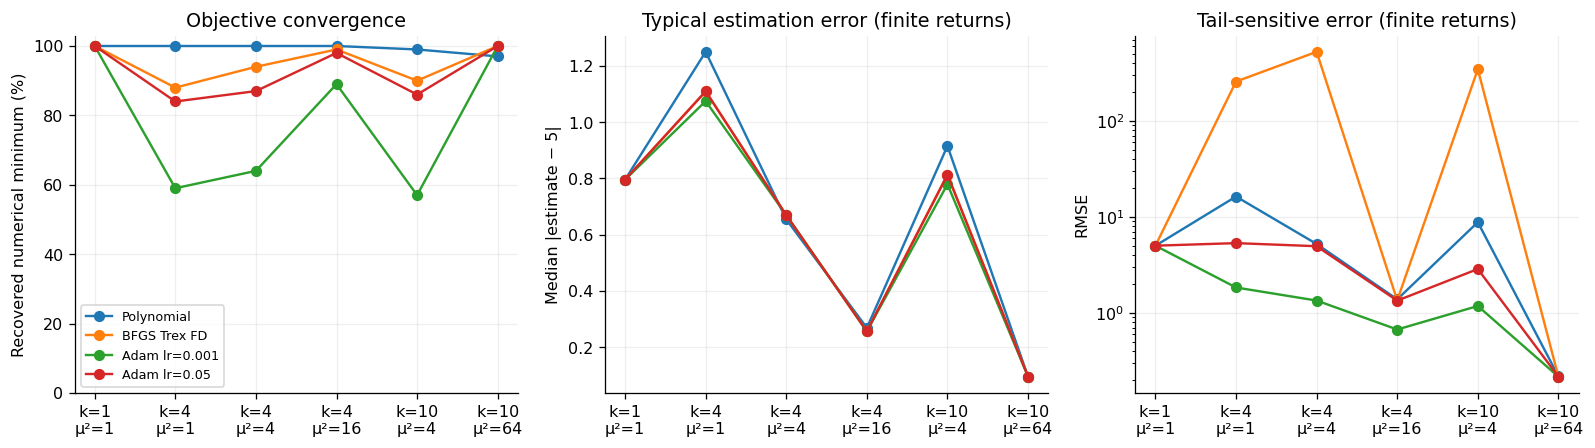

In [5]:
methods=["Polynomial","BFGS Trex FD","Adam lr=0.001","Adam lr=0.05"]
configs=[(1,1),(4,1),(4,4),(4,16),(10,4),(10,64)]
fig,axes=plt.subplots(1,3,figsize=(14,4))
xx=np.arange(len(configs))
for j,method in enumerate(methods):
    part=summary.xs(method,level="method").reindex(pd.MultiIndex.from_tuples(configs,names=["k","concentration"]))
    axes[0].plot(xx,part["objective_recovered_%"],marker="o",label=method)
    axes[1].plot(xx,part["median_abs_error"],marker="o",label=method)
    axes[2].plot(xx,part["RMSE"],marker="o",label=method)
labels=[f"k={k}\nμ²={mu}" for k,mu in configs]
for ax in axes: ax.set_xticks(xx,labels); ax.grid(alpha=.2)
axes[0].set(ylabel="Recovered numerical minimum (%)",ylim=(0,103),title="Objective convergence")
axes[1].set(ylabel="Median |estimate − 5|",title="Typical estimation error (finite returns)")
axes[2].set(ylabel="RMSE",yscale="log",title="Tail-sensitive error (finite returns)")
axes[0].legend(fontsize=8,loc="lower left")
fig.tight_layout();plt.show()

### Paired uncertainty in typical estimation error

For each reduced-form configuration, compare absolute errors of BFGS-from-2SLS and the polynomial result **on the same dataset**. Positive differences favor the polynomial estimate. The interval bootstraps the median paired difference over datasets (2,000 resamples). These small, six-design comparisons are descriptive; they do not establish a general risk ordering. Polynomial refusals are excluded only from this paired comparison and the number of usable pairs is shown.

In [6]:
poly = primary[primary.method.eq("Polynomial")][keys+["error"]].rename(columns={"error":"poly_error"})
pair = primary[primary.method.eq("BFGS Trex FD") & primary.start.eq("2SLS")].merge(poly,on=keys)
rng=np.random.default_rng(1030)
intervals=[]
for (k,mu),g in pair.groupby(["k","concentration"]):
    g=g[np.isfinite(g.error)&np.isfinite(g.poly_error)]
    delta=g.error.abs().to_numpy()-g.poly_error.abs().to_numpy()
    boot=np.median(rng.choice(delta,size=(2000,len(delta)),replace=True),axis=1)
    intervals.append({"k":k,"mu²":mu,"pairs":len(delta),"median paired |error| difference":np.median(delta),
                      "bootstrap 2.5%":np.quantile(boot,.025),"bootstrap 97.5%":np.quantile(boot,.975)})
display(pd.DataFrame(intervals).round(4))

,k,mu²,pairs,median paired |error| difference,bootstrap 2.5%,bootstrap 97.5%
0,1,1,100,0.0,-0.0,0.0
1,4,1,100,-0.0,-0.0,-0.0
2,4,4,100,-0.0,-0.0,0.0
3,4,16,100,-0.0,-0.0,0.0
4,10,4,99,-0.0,-0.0,-0.0
5,10,64,97,-0.0,-0.0,0.0


## 3. A local-convergence failure, inspected directly

This illustration deliberately selects the **largest objective gap for BFGS-from-zero among the saved $k=4,\mu^2=1$ datasets**. It is a failure diagnostic, not a representative draw or the basis of the aggregate estimates above. The full sample and every seed remain available. The objective plot uses $\beta=\tan(\theta)$ to display both tails without truncating the coefficient search.

{'seed': 940035, 'BFGS_zero_objective_gap': 17.133367195846184, 'polynomial_beta': 7.515275477851465}


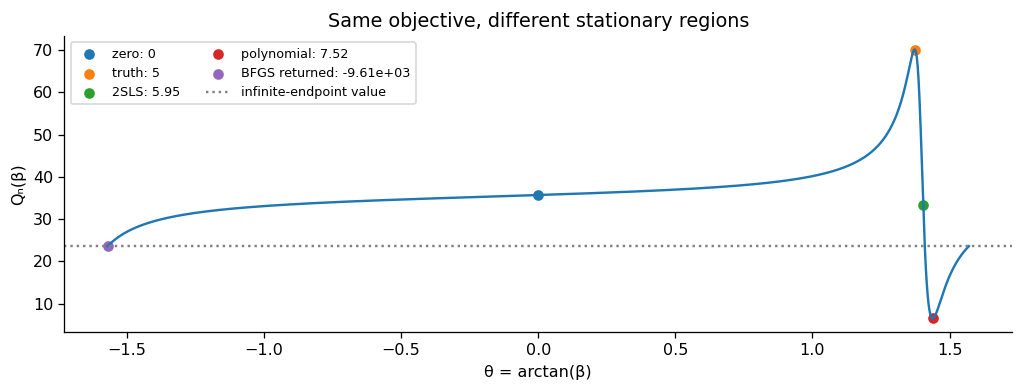

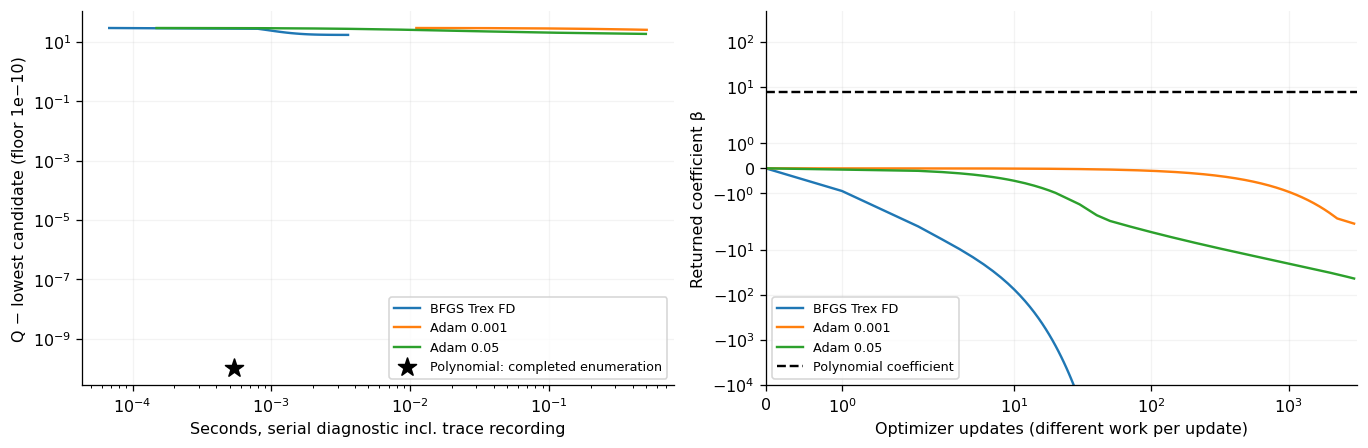

,method,beta,objective,gradient,iterations,success
0,BFGS,-9614.077549,23.632879,7.089375e-07,27,True
1,Adam 0.001,-2.611439,31.884719,1.014488e+00,3000,False
2,Adam 0.05,-43.222207,24.982105,2.801015e-02,3000,False


In [7]:
selection=primary[(primary.k==4)&(primary.concentration==1)&primary.method.eq("BFGS Trex FD")&primary.start.eq("zero")]
case=selection.loc[selection.objective_gap.idxmax()]
z,y,x,tsls=generate(int(case.seed),4,1)
p=ScalarIVCUE.from_data(z,y,x,demean=False)
r=p.minimize_polynomial()
print({"seed":int(case.seed),"BFGS_zero_objective_gap":float(case.objective_gap),"polynomial_beta":r.beta})
angles=np.linspace(-np.pi/2+1e-6,np.pi/2-1e-6,2000)
fig,ax=plt.subplots(figsize=(9,3.5))
ax.plot(angles,[p.value(np.tan(t)) for t in angles],lw=1.5)
for label,beta in [("zero",0.),("truth",5.),("2SLS",tsls),("polynomial",r.beta),("BFGS returned",case.beta)]:
    ax.scatter(np.arctan(beta),p.value(beta),s=32,label=f"{label}: {beta:.3g}")
ax.axhline(p.value(np.inf),ls=":",color="gray",label="infinite-endpoint value")
ax.set(xlabel="θ = arctan(β)",ylabel="Qₙ(β)",title="Same objective, different stationary regions")
ax.legend(fontsize=8,ncol=2);fig.tight_layout();plt.show()

btrace=bfgs(p,0.,trace=True)
adam_traces={}
for lr in [.001,.05]:
    fits,history,elapsed=adam_batch([p],[0.],lr=lr,trace=True)
    adam_traces[lr]=(fits[0],history)
fig,axes=plt.subplots(1,2,figsize=(12,4))
t=pd.DataFrame(btrace["trace"])
axes[0].plot(t.seconds,np.maximum(t.objective-r.fun,1e-10),label="BFGS Trex FD")
axes[1].plot(np.arange(len(t)),t.beta,label="BFGS Trex FD")
for lr,(fit,history) in adam_traces.items():
    seconds=np.array([h["seconds"] for h in history]);objs=np.array([h["objective"][0] for h in history])
    axes[0].plot(seconds,np.maximum(objs-r.fun,1e-10),label=f"Adam {lr}")
    axes[1].plot([h["iteration"] for h in history],[h["beta"][0] for h in history],label=f"Adam {lr}")
# Enumeration is not an iterative descent; plot its completed computation as one point.
axes[0].scatter([r.elapsed_seconds],[1e-10],marker="*",s=140,color="black",label="Polynomial: completed enumeration")
axes[1].axhline(r.beta,color="black",ls="--",label="Polynomial coefficient")
axes[0].set(xscale="log",yscale="log",xlabel="Seconds, serial diagnostic incl. trace recording",ylabel="Q − lowest candidate (floor 1e−10)")
axes[1].set(xscale="symlog",yscale="symlog",xlabel="Optimizer updates (different work per update)",ylabel="Returned coefficient β", xlim=(0, None))
for ax in axes:ax.legend(fontsize=8);ax.grid(alpha=.15)
fig.tight_layout();plt.show()
display(pd.DataFrame([{ "method":"BFGS", **{k:btrace[k] for k in ["beta","objective","gradient","iterations","success"]}},
                      *[{"method":f"Adam {lr}", **{k:fit[k] for k in ["beta","objective","gradient","iterations","success"]}}
                        for lr,(fit,_) in adam_traces.items()]]))

## 4. Timings and batch-equivalence check

The Monte Carlo batches independent Adam fits to keep the experiment small. Its amortized timings are not comparable to serial BFGS or polynomial calls. Below, all methods instead run **serially**, starting from 2SLS on one fixed stronger-IV dataset, with one warm-up and five measured fits. Common `from_data` preprocessing is timed separately. Setup/compilation/GPU transfers are not hidden: this is CPU/float64, with no compilation. Timings measure this implementation and machine, not a universal optimizer speed ranking. A fast incomplete fit is not presented as a converged solution.

In [8]:
from time import perf_counter
z,y,x,tsls=generate(103099,4,16)
setup=[]
for _ in range(5):
    begin=perf_counter(); timing_problem=ScalarIVCUE.from_data(z,y,x,demean=False);setup.append(perf_counter()-begin)
serial=[]
for name in ["Polynomial","BFGS Trex FD","BFGS analytic","Adam lr=0.001","Adam lr=0.05"]:
    times=[];success=[]
    for repetition in range(6):
        begin=perf_counter()
        if name=="Polynomial":
            fit=timing_problem.minimize_polynomial();ok=True
        elif name.startswith("BFGS"):
            fit=bfgs(timing_problem,tsls,analytic=name.endswith("analytic"));ok=fit["success"]
        else:
            fit,_,_=adam_batch([timing_problem],[tsls],lr=float(name.split("=")[1]));ok=fit[0]["success"]
        elapsed=perf_counter()-begin
        if repetition:times.append(1000*elapsed);success.append(ok)
    serial.append({"method":name,"median ms":np.median(times),"min ms":min(times),"max ms":max(times),"stopping rule met":all(success)})
print(f"Common moment/covariance preprocessing: median {1000*np.median(setup):.3f} ms")
display(pd.DataFrame(serial).round(3))
# Check batching does not change Adam gradients/state or stopping behavior.
starts=[tsls,0.,5.]
batched,_,_=adam_batch([timing_problem]*3,starts,lr=.05)
separate=[adam_batch([timing_problem],[s],lr=.05)[0][0] for s in starts]
np.testing.assert_allclose([f["beta"] for f in batched],[f["beta"] for f in separate],rtol=1e-10,atol=1e-10)
assert [f["iterations"] for f in batched]==[f["iterations"] for f in separate]
print("Batched vs separate Adam: estimates and stopping iterations agree.")

Common moment/covariance preprocessing: median 0.235 ms


,method,median ms,min ms,max ms,stopping rule met
0,Polynomial,0.485,0.421,0.591,True
1,BFGS Trex FD,0.577,0.537,0.616,True
2,BFGS analytic,0.415,0.403,0.434,True
3,Adam lr=0.001,30.871,30.760,31.026,True
4,Adam lr=0.05,36.092,35.721,36.546,True


Batched vs separate Adam: estimates and stopping iterations agree.


## 5. Connection to the existing GEL/CUE implementation

This section runs the **actual existing** `GELEstimator(..., rho=rho_cue, min_method="BFGS")`. It does not substitute a reduced-form covariance into an existing raw-moment GEL fit. Pointwise equality checks account for the $1/(2n)$ normalization. Optimizer comparisons then use `weighting="raw"` for every method.

BFGS in the main panels uses the same SciPy optimizer and numerical differentiation convention as Trex's GMM path, but a CUE objective instead of two-step GMM. This distinction is essential: comparing two different statistical estimators would not isolate the numerical recipe.

In [9]:
bridge=[]
for seed in [103111,103112,103113]:
    z,y,x,tsls=generate(seed,4,4)
    D=np.column_stack([y,x,z])
    m=lambda d,b: d[:,2:]*(d[:,0]-b[0]*d[:,1])[:,None]
    gel=GELEstimator(m,rho=rho_cue,min_method="BFGS")
    raw=ScalarIVCUE.from_data(z,y,x,weighting="raw",demean=False)
    for beta in [0.,tsls,5.]:
        profile,gradient=gel._profile_value_gradient(np.array([beta]),D,np.zeros(4))
        q,dq,_=raw.value_derivatives(beta)
        np.testing.assert_allclose(2*len(D)*profile,q,rtol=1e-9)
        np.testing.assert_allclose(2*len(D)*gradient[0],dq,rtol=1e-6,atol=1e-7)
    try:
        gel.fit(D,np.array([tsls]));message="success";estimate=gel.est[0]
    except RuntimeError as exc:
        message=str(exc);estimate=gel.result_.x[0] if hasattr(gel,"result_") else np.nan
    poly=raw.minimize_polynomial()
    bridge.append({"seed":seed,"GEL beta":estimate,"polynomial beta":poly.beta,
                   "GEL Q gap":raw.value(estimate)-poly.fun,"existing GEL status":message})
display(pd.DataFrame(bridge))
raw_summary=df[df.weighting.eq("raw") & (df.start.eq("2SLS") | df.method.eq("Polynomial"))].groupby("method").apply(summarize, include_groups=False)
display(raw_summary.round(3))

,seed,GEL beta,polynomial beta,GEL Q gap,existing GEL status
0,103111,9.434856,9.434856,0.000000e+00,success
1,103112,10.738477,10.738488,6.838974e-13,success
2,103113,4.392783,4.392783,4.440892e-16,success


,N,finite_N,optimizer_success_%,objective_recovered_%,median_bias,median_abs_error,RMSE,90%_range
method,,,,,,,,
Adam lr=0.001,100.0,100.0,78.0,84.0,0.087,0.446,1.150,3.561
Adam lr=0.05,100.0,100.0,97.0,96.0,0.087,0.446,2.646,4.109
BFGS Trex FD,100.0,100.0,100.0,98.0,0.087,0.446,88.320,4.109
BFGS analytic,100.0,100.0,100.0,98.0,0.087,0.446,88.320,4.109
Polynomial,100.0,100.0,100.0,100.0,0.123,0.455,5.479,5.112


## 6. Interpretation and implementation boundary

**Numerical conclusion.** The root-enumeration characterization is useful: an iterative optimizer can meet its stopping criterion while missing the lowest CUE candidate. An analytic BFGS gradient does not remove nonconvexity or the flat-tail stopping problem. A 2SLS start improves reliability substantially; the infeasible true start is not a guarantee. Adam's default learning rate can be slow, and increasing it is not a global-search procedure.

**Statistical conclusion.** Global CUE computation is not automatic risk reduction. In the weakest overidentified design here, the polynomial estimator has *larger* median absolute error than local BFGS-from-2SLS. A local/stopped fit can appear accurate because of its start or implicit regularization. That does not make it the CUE estimator defined by global minimization. Weak-IV tails and only 100 draws per configuration make finite-sample risk claims especially provisional. No conventional standard errors or CLR critical values are supplied.

**Numerical limits are visible.** Four of 700 polynomial attempts were refused (all at ten instruments). These are counted in recovery rates and shown explicitly. The remaining objective matches are excellent but do not turn float64 interpolation, eigenvalue classification or a dense grid into an algebraic certificate. The twelve-instrument cap is conservative, not an established guarantee of reliability up to twelve; the paper considers as many as sixty instruments.

### Next implementation steps

1. Add adaptive precision and root isolation, with interval/backward-error checks for near-multiple roots and denominator conditioning. Recover the four refused cases before expanding the supported instrument dimension.
2. Keep an explicit distinction between raw structural-moment CUE and fixed reduced-form covariance CUE in any future estimator-level API. Preserve the current two-step GMM default.
3. For several endogenous regressors, construct polynomial stationary systems and the **direction-dependent boundary problem**. The paper's elimination/homotopy and real-feasibility steps cannot be replaced by coordinatewise scalar minimization with a global claim.
4. Treat singular covariance as a separate implementation: identify rank-drop points before cancellation, use the intended pseudoinverse criterion and check interval/end-point limits. A ridge changes the objective and must be a named option, not a hidden repair.
5. Validate additional included-covariate projections and dependence designs. HC0/HAC/one-way cluster covariance builders are numerically tested; the current Monte Carlo is iid and demeans only an intercept.
6. Add inference only with its required identification assumptions. A correctly computed objective is a numerical input to inference, not an inference procedure by itself.

### Artifacts

- Prototype: [`trex/gmm/cue.py`](../trex/gmm/cue.py).
- Independent tests: [`tests/test_cue_polynomial.py`](../tests/test_cue_polynomial.py).
- DGP, BFGS and batched Adam runner: [`experiment.py`](../benchmarks/cue_polynomial/experiment.py).
- Every dataset seed and optimizer return: [`results.json.gz`](../benchmarks/cue_polynomial/results.json.gz).
- Source provenance and pinned re-download: [`source/`](../benchmarks/cue_polynomial/source/).

The primary scientific reference is arXiv:2609.36445v1, Sections 2, 3.1–3.3 and 5.1. The notebook's numerical safeguards, extra strong-IV configuration, Adam benchmarks and limitations are part of this independent Trex experiment.